In [2]:
from mtcnn import MTCNN
from facenet_pytorch import InceptionResnetV1
from PIL import Image as PILImage
import torch
import numpy as np
import cv2
import pickle
import os
from IPython.display import display
from PIL import Image

# Charger les modeles
detector = MTCNN()
model = InceptionResnetV1(pretrained='vggface2').eval()
print("MTCNN + FaceNet charges !")

def aligner_visage_mtcnn(image_rgb, face):
    keypoints = face['keypoints']
    left_eye  = keypoints['left_eye']
    right_eye = keypoints['right_eye']

    # Calculer l'angle de rotation
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = np.degrees(np.arctan2(dy, dx))

    # Convertir explicitement en float
    centre = (
        float((left_eye[0] + right_eye[0]) / 2),
        float((left_eye[1] + right_eye[1]) / 2)
    )

    # Rotation
    h_img, w_img = image_rgb.shape[:2]
    M = cv2.getRotationMatrix2D(centre, angle, 1.0)
    image_alignee = cv2.warpAffine(image_rgb, M, (w_img, h_img))

    # Extraire le crop avec marge
    x, y, w, h = face['box']
    x = max(0, x)
    y = max(0, y)
    marge = int(max(w, h) * 0.2)
    x1 = max(0, x - marge)
    y1 = max(0, y - marge)
    x2 = min(w_img, x + w + marge)
    y2 = min(h_img, y + h + marge)

    return image_alignee[y1:y2, x1:x2], (x1, y1, x2, y2)

def extraire_embedding(crop_rgb):
    """Extrait l'embedding depuis un crop RGB aligne"""
    if crop_rgb is None or crop_rgb.size == 0:
        return None
    img = PILImage.fromarray(crop_rgb).resize((160, 160))
    img_tensor = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0)
    with torch.no_grad():
        embedding = model(img_tensor)
    return embedding[0].numpy()


# Construire la base 
base_de_visages = {}
dossier_photos = "photos_connues"

print("\nConstruction de la base\n")

for fichier in os.listdir(dossier_photos):
    if not fichier.endswith(('.png', '.jpg', '.jpeg')):
        continue

    nom = os.path.splitext(fichier)[0]
    chemin = os.path.join(dossier_photos, fichier)
    image_cv = cv2.imread(chemin)

    if image_cv is None:
        print(f" Impossible de lire {fichier}")
        continue

    # Redimensionner si trop grande
    h_img, w_img = image_cv.shape[:2]
    max_dim = 1280
    if max(w_img, h_img) > max_dim:
        scale = max_dim / max(w_img, h_img)
        image_cv = cv2.resize(image_cv, (int(w_img*scale), int(h_img*scale)))

    image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

    # Detecter le visage
    faces = detector.detect_faces(image_rgb)

    if not faces:
        print(f" Aucun visage detecte dans {fichier}")
        continue

    # Prendre le visage avec la meilleure confiance
    face = max(faces, key=lambda f: f['confidence'])
    confidence = face['confidence']
    print(f" {fichier} : confiance detection = {confidence:.2f}")

    # Aligner et extraire
    crop, (x1, y1, x2, y2) = aligner_visage_mtcnn(image_rgb, face)

    # Afficher le visage detecte
    image_affichage = image_cv.copy()
    cv2.rectangle(image_affichage, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(image_affichage, nom, (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    #display(Image.fromarray(cv2.cvtColor(image_affichage, cv2.COLOR_BGR2RGB)))

    embedding = extraire_embedding(crop)
    if embedding is not None:
        base_de_visages[nom] = embedding
        print(f" Enregistre : {nom}\n")
    else:
        print(f" Echec embedding : {nom}\n")

print(f"Base construite : {len(base_de_visages)} personne(s)")
print(f"Personnes : {list(base_de_visages.keys())}")

with open("base_visages.pkl", "wb") as f:
    pickle.dump(base_de_visages, f)
print(" Base sauvegardee !")

MTCNN + FaceNet charges !

Construction de la base

 sheksony.jpg : confiance detection = 1.00
 Enregistre : sheksony



[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


 junior.jpg : confiance detection = 1.00
 Enregistre : junior

 vivien.jpg : confiance detection = 0.99
 Enregistre : vivien

 benji.jpeg : confiance detection = 0.99
 Enregistre : benji

Base construite : 4 personne(s)
Personnes : ['sheksony', 'junior', 'vivien', 'benji']
 Base sauvegardee !


Base chargee : ['sheksony', 'junior', 'vivien', 'benji']

2 visage(s) detecte(s)

Visage 1 (confiance detection : 1.00) :
    Distances : {'sheksony': 0.622, 'junior': 0.729, 'vivien': 0.056, 'benji': 0.355}
  Resultat : vivien (94.4%)

Visage 2 (confiance detection : 1.00) :
    Distances : {'sheksony': 0.642, 'junior': 0.502, 'vivien': 0.374, 'benji': 0.081}
  Resultat : benji (91.9%)


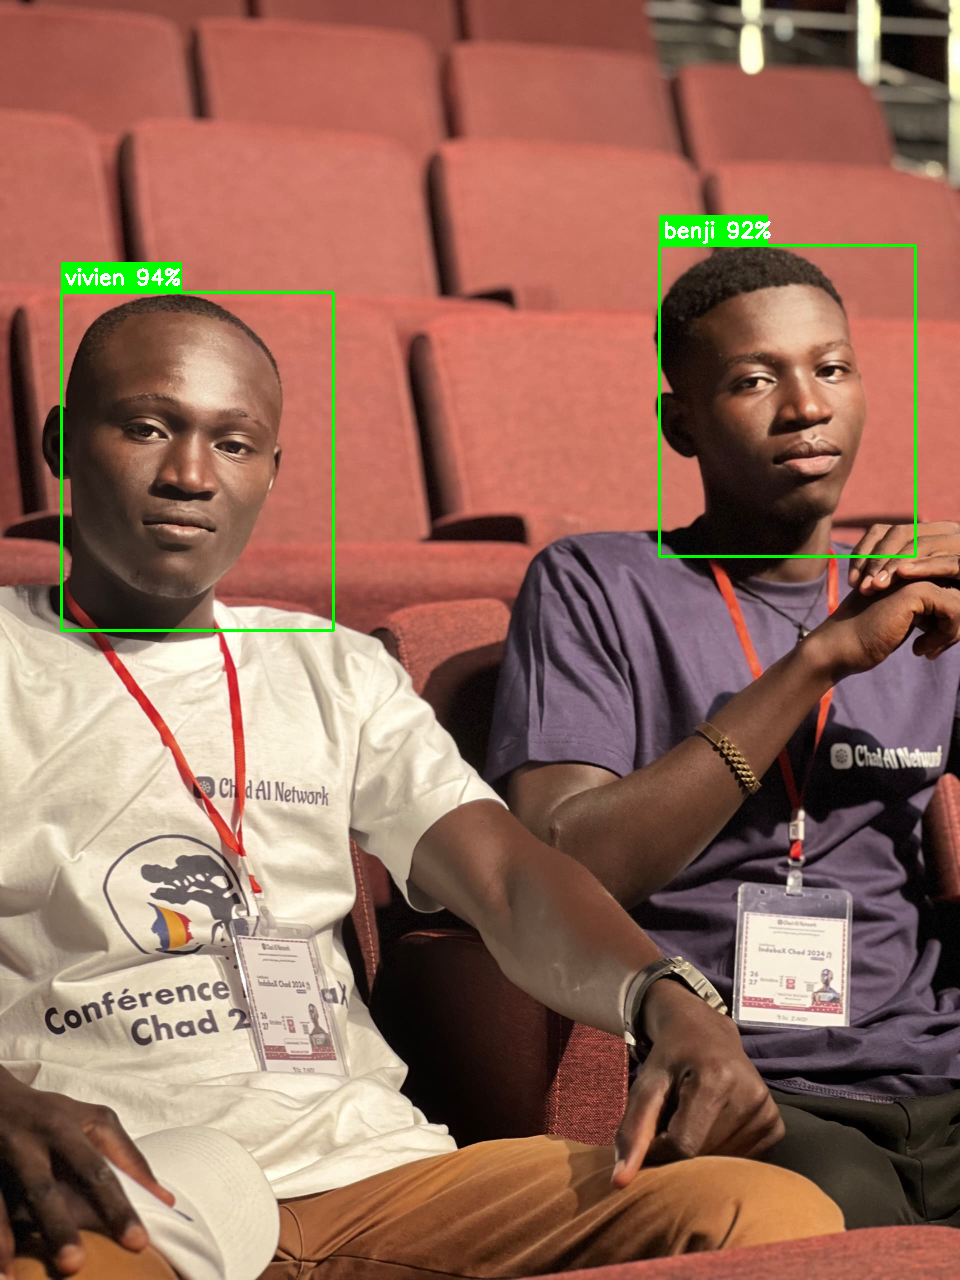

In [4]:
from mtcnn import MTCNN
from facenet_pytorch import InceptionResnetV1
from PIL import Image as PILImage
import torch
import numpy as np
import cv2
import pickle
from IPython.display import display
from PIL import Image

# Charger la base et les modeles
with open("base_visages.pkl", "rb") as f:
    base_de_visages = pickle.load(f)
print(f"Base chargee : {list(base_de_visages.keys())}")

detector = MTCNN()
model = InceptionResnetV1(pretrained='vggface2').eval()

def distance_cosinus(vec1, vec2):
    dot = np.dot(vec1, vec2)
    norme = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    return 1 - (dot / norme) if norme != 0 else 1.0

def identifier_visage(crop_rgb, base, seuil=0.5):
    """Identifie un visage en le comparant a la base."""
    embedding_inconnu = extraire_embedding(crop_rgb)
    if embedding_inconnu is None:
        return "Erreur", 0.0

    meilleur_nom = "Inconnu"
    meilleure_distance = seuil
    toutes_distances = {}

    for nom, embedding_connu in base.items():
        distance = distance_cosinus(embedding_inconnu, embedding_connu)
        toutes_distances[nom] = round(distance, 3)
        if distance < meilleure_distance:
            meilleure_distance = distance
            meilleur_nom = nom

    print(f"    Distances : {toutes_distances}")
    confiance = max(0, (1 - meilleure_distance) * 100)
    return meilleur_nom, confiance

# Reconnaissance sur l'image
image_cv = cv2.imread('yo.jpg')

# Redimensionner si necessaire
h_img, w_img = image_cv.shape[:2]
max_dim = 1280
if max(w_img, h_img) > max_dim:
    scale = max_dim / max(w_img, h_img)
    image_cv = cv2.resize(image_cv, (int(w_img*scale), int(h_img*scale)))

image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)
faces = detector.detect_faces(image_rgb)
print(f"\n{len(faces)} visage(s) detecte(s)")

for i, face in enumerate(faces):
    confidence = face['confidence']
    print(f"\nVisage {i+1} (confiance detection : {confidence:.2f}) :")

    # Aligner le visage
    crop, (x1, y1, x2, y2) = aligner_visage_mtcnn(image_rgb, face)

    if crop.size == 0:
        continue

    # Identifier
    nom, confiance_id = identifier_visage(crop, base_de_visages)
    print(f"  Resultat : {nom} ({confiance_id:.1f}%)")

    # Couleur verte si reconnu, rouge si inconnu
    couleur = (0, 255, 0) if nom != "Inconnu" else (0, 0, 255)

    # Dessiner
    cv2.rectangle(image_cv, (x1, y1), (x2, y2), couleur, 2)
    label = f"{nom} {confiance_id:.0f}%"
    cv2.rectangle(image_cv, (x1, y1-30), (x1+len(label)*12, y1), couleur, -1)
    cv2.putText(image_cv, label, (x1+4, y1-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # Dessiner les 5 points cles
    #for kp_name, (kp_x, kp_y) in face['keypoints'].items():
        #cv2.circle(image_cv, (kp_x, kp_y), 3, (255, 255, 0), -1)

# Afficher le resultat
display(Image.fromarray(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)))